# Compuerta del enriquecimiento

`src/enrich.py` agrega contexto del barrio al stage limpio. Este notebook no celebra que
esas columnas existan: **mide cuáles aportan y cuáles había que borrar**.

El resultado ya se aplicó. De los cinco bloques que se probaron, sobrevivieron dos.

## Protocolo, y por qué es así

- **Un modelo por operación.** Canon mensual y precio de venta no comparten escala.
- **Target `log(precio)`**, error reportado como MAE en log (≈ error relativo).
- **Split agrupado, siempre.** El 8-12 % de las filas son near-duplicados (mismo proyecto
  republicado): con split aleatorio la unidad 3 queda en train y la 7 en test, el modelo ya
  vio la respuesta y la métrica miente.
- **Subconjunto único**: sólo filas con coordenada. Comparar un baseline sobre 44.833 filas
  contra un enriquecido sobre 18.000 no significa nada.

## Dos regímenes, no uno

Acá está la corrección al EDA anterior, que medía sólo con `GroupKFold` sobre
near-duplicados. Ese split deja casi todos los barrios presentes en train **y** en test: en
ese régimen `lat`/`lon` ya tiene el barrio memorizado y cualquier otra feature de barrio
parece redundante.

Pero en producción va a llegar un anuncio de un barrio que el modelo **nunca vio**. Ahí las
coordenadas sólo pueden interpolar de los vecinos, mientras que "este barrio es estrato 5"
es una regla que **transfiere**.

| régimen | agrupación | qué pregunta responde |
|---|---|---|
| **conocido** | near-duplicado | ¿cuánto mejora con barrios ya vistos? |
| **arranque en frío** | barrio | ¿cuánto mejora con un barrio nuevo? |

Un bloque que sólo aporta en arranque en frío **se queda igual**: ese es el caso real.

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

PROCESADO = pathlib.Path("..").resolve() / "data" / "processed"
df = pd.read_parquet(PROCESADO / "anuncios_enriquecido.parquet")
resumen = json.loads((PROCESADO / "enrich_resumen.json").read_text(encoding="utf-8"))

OPERACIONES = {"arriendo": "precio_arriendo", "venta": "precio_venta"}
BLOQUES = {
    "coordenadas": ["lat_barrio", "lon_barrio", "distancia_centro_km"],
    "estrato": ["estrato_modal", "estrato_promedio", "estrato_dispersion"],
}

print(f"filas: {len(df):,} | columnas: {df.shape[1]}")
print(f"cobertura global: {resumen['cobertura_%']} % | en el recorte: "
      f"{resumen['cobertura_en_recorte_%']} %")

filas: 44,833 | columnas: 49
cobertura global: 40.2 % | en el recorte: 47.2 %


## 1. Hasta dónde llegó el enriquecimiento

Antes de medir el lift hay que saber **sobre cuántas filas** se puede medir. La comparación
honesta contra el prototipo del EDA es **por ciudad**: su 43,9 % global promediaba
Barranquilla al 82,9 % con Bogotá al 32,0 %, y cubría 5 ciudades, no 15.

In [2]:
BASE_PROTOTIPO = {"bogota d.c.": 32.0, "medellin": 66.5, "envigado": 3.6,
                  "barranquilla": 82.9, "cali": 44.5}

cobertura = pd.DataFrame({
    "anuncios": df["ciudad_clave"].value_counts(),
    "cobertura_%": pd.Series(resumen["cobertura_por_ciudad_%"]),
    "prototipo_%": pd.Series(BASE_PROTOTIPO),
}).dropna(subset=["cobertura_%"])
cobertura["delta"] = (cobertura["cobertura_%"] - cobertura["prototipo_%"]).round(1)
display(cobertura.sort_values("anuncios", ascending=False))

print("match:", resumen["match"])
print("con estrato:", resumen["con_estrato_%"], "%")

,anuncios,cobertura_%,prototipo_%,delta
bogota d.c.,13674,40.0,32.0,8.0
medellin,8239,67.9,66.5,1.4
envigado,3011,32.3,3.6,28.7
barranquilla,2483,82.7,82.9,-0.2
cali,2209,52.6,44.5,8.1
pereira,1410,5.5,NaN,NaN
chia,1356,21.2,NaN,NaN
rionegro,1113,40.1,NaN,NaN
cartagena de indias,865,54.3,NaN,NaN
cajica,805,45.6,NaN,NaN


match: {'sin_match': 26257, 'exacto': 18021, 'descartado_por_municipio': 555}
con estrato: 37.2 %


## 2. El estrato, antes de meterlo a un modelo

Mirar la correlación cruda con el precio engaña: casi todo correlaciona con el precio
porque casi todo correlaciona con "es una ciudad cara". Se mide contra `log(precio/m²)`
**centrado por ciudad**, que deja sólo la variación *dentro* de cada ciudad — lo que el
modelo todavía no sabe.

Si el estrato sirve, la mediana de precio/m² tiene que crecer de forma monótona del 1 al 6.

In [3]:
con_coordenada = df["lat_barrio"].notna()
numericas = BLOQUES["coordenadas"] + BLOQUES["estrato"]

for nombre, columna in OPERACIONES.items():
    sub = df[df[columna].notna() & con_coordenada]
    y = np.log(sub["precio_m2"].astype("float64"))
    centrado = y - y.groupby(sub["ciudad_clave"]).transform("mean")
    correlaciones = {c: sub[c].astype("float64").corr(centrado, method="spearman")
                     for c in numericas}
    print(f"=== {nombre.upper()} (n={len(sub):,}) — Spearman con log(precio/m²) "
          f"centrado por ciudad ===")
    print(pd.Series(correlaciones).dropna().sort_values(ascending=False).round(3).to_string())
    print()

=== ARRIENDO (n=10,022) — Spearman con log(precio/m²) centrado por ciudad ===
estrato_dispersion     0.166
estrato_modal          0.117
distancia_centro_km    0.103
lon_barrio             0.076
estrato_promedio       0.057
lat_barrio            -0.085

=== VENTA (n=7,999) — Spearman con log(precio/m²) centrado por ciudad ===
estrato_dispersion     0.170
estrato_modal          0.065
estrato_promedio       0.037
lon_barrio             0.015
distancia_centro_km   -0.029
lat_barrio            -0.071



C:\Users\juanj\AppData\Local\Temp\ipykernel_4024\122802689.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eje.boxplot(datos, labels=[int(e) for e in sorted(sub["estrato_modal"].dropna().unique())],
C:\Users\juanj\AppData\Local\Temp\ipykernel_4024\122802689.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eje.boxplot(datos, labels=[int(e) for e in sorted(sub["estrato_modal"].dropna().unique())],


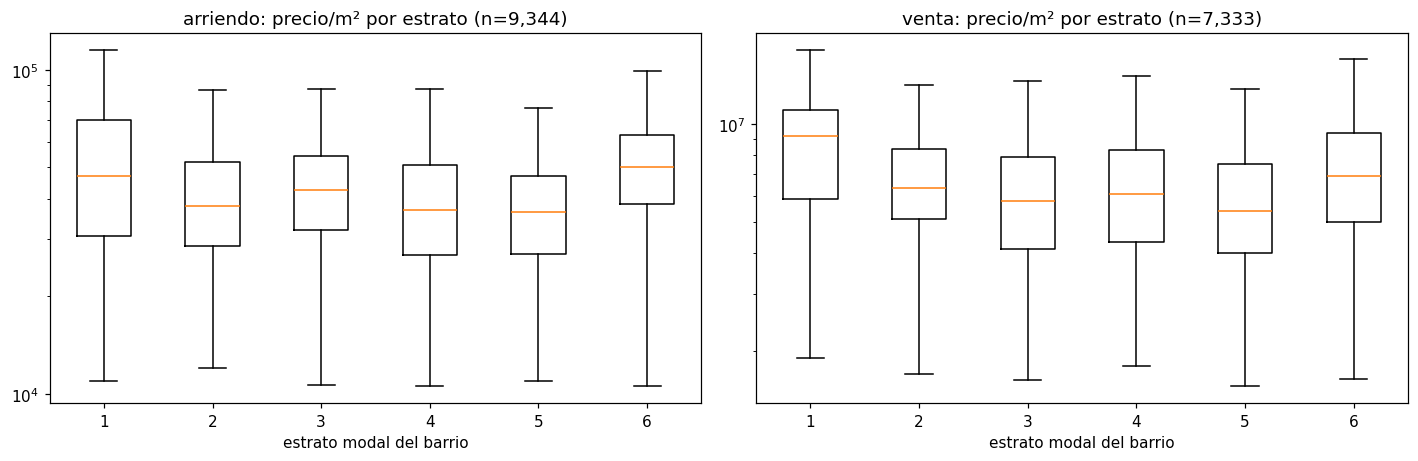

=== ARRIENDO ===


,count,median,vs_estrato_3
estrato_modal,,,
1.0,156,47122.0,1.11
2.0,629,38095.0,0.89
3.0,2311,42609.0,1.0
4.0,1508,36938.0,0.87
5.0,1728,36344.0,0.85
6.0,3012,50000.0,1.17


=== VENTA ===


,count,median,vs_estrato_3
estrato_modal,,,
1.0,257,9200000.0,1.59
2.0,934,6333333.0,1.09
3.0,1456,5785646.0,1.0
4.0,1444,6101981.0,1.05
5.0,1572,5414216.0,0.94
6.0,1670,6941964.0,1.2


In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.3))
for eje, (nombre, columna) in zip(ejes, OPERACIONES.items()):
    sub = df[df[columna].notna() & df["estrato_modal"].notna()]
    datos = [sub.loc[sub["estrato_modal"] == e, "precio_m2"].dropna()
             for e in sorted(sub["estrato_modal"].dropna().unique())]
    eje.boxplot(datos, labels=[int(e) for e in sorted(sub["estrato_modal"].dropna().unique())],
                showfliers=False)
    eje.set_yscale("log")
    eje.set_title(f"{nombre}: precio/m² por estrato (n={len(sub):,})")
    eje.set_xlabel("estrato modal del barrio")
plt.tight_layout()
plt.show()

for nombre, columna in OPERACIONES.items():
    sub = df[df[columna].notna() & df["estrato_modal"].notna()]
    tabla = sub.groupby("estrato_modal")["precio_m2"].agg(["count", "median"]).round(0)
    tabla["vs_estrato_3"] = (tabla["median"] / tabla["median"].get(3, np.nan)).round(2)
    print(f"=== {nombre.upper()} ===")
    display(tabla)

## 3. La ablación

In [5]:
BASE_NUMERICAS = ["log_area", "habitaciones", "banos", "parqueaderos"]
BASE_BANDERAS = ["habitaciones_es_tope", "banos_es_tope", "parqueaderos_es_tope"]
BASE_CATEGORICAS = ["tipo_inmueble", "ciudad_clave"]
TOPE_CATEGORIAS = 255   # límite nativo de HistGradientBoostingRegressor


def preparar(operacion):
    columna = OPERACIONES[operacion]
    sub = df[df[columna].notna() & df["lat_barrio"].notna()].copy()
    sub["precio"] = sub[columna].astype("float64")
    sub["log_precio"] = np.log(sub["precio"])
    sub["log_area"] = np.log(sub["area_m2"].astype("float64"))
    return sub.reset_index(drop=True)


def codificar(serie, tope=TOPE_CATEGORIAS):
    """Códigos enteros, agrupando la cola larga en una sola categoría 'otros'."""
    serie = serie.astype(str).fillna("desconocido")
    frecuentes = serie.value_counts().head(tope - 1).index
    return serie.where(serie.isin(frecuentes), "otros").astype("category").cat.codes


def grupos_de(sub, regimen):
    if regimen == "conocido":
        # Near-duplicados: mismo proyecto o anuncio republicado.
        llave = (sub["ciudad_clave"].astype(str) + "|" + sub["sector_clave"].astype(str) + "|"
                 + sub["tipo_inmueble"].astype(str) + "|" + sub["area_m2"].astype(str) + "|"
                 + sub["precio"].astype(str))
    else:
        # Arranque en frío: el barrio entero cae de un solo lado del split.
        llave = sub["ciudad_clave"].astype(str) + "|" + sub["barrio_osm"].astype(str)
    return llave.factorize()[0]


def evaluar(sub, extras=(), etiqueta="", regimen="conocido", folds=5):
    X = sub[BASE_NUMERICAS].astype("float32").copy()
    for columna in BASE_BANDERAS:
        X[columna] = sub[columna].astype("float32")
    categoricas = []
    for columna in BASE_CATEGORICAS:
        X[columna] = codificar(sub[columna]).astype("float32")
        categoricas.append(X.columns.get_loc(columna))
    for columna in extras:
        X[columna] = pd.to_numeric(sub[columna], errors="coerce").astype("float32")

    y = sub["log_precio"].to_numpy()
    grupos = grupos_de(sub, regimen)
    prediccion = np.empty(len(y))
    for train, test in GroupKFold(folds).split(X, y, grupos):
        modelo = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=.07, categorical_features=categoricas,
            random_state=0)
        modelo.fit(X.iloc[train], y[train])
        prediccion[test] = modelo.predict(X.iloc[test])

    r2 = 1 - ((y - prediccion) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return {"escenario": etiqueta, "regimen": regimen, "n": len(y), "features": X.shape[1],
            "R2": round(float(r2), 3),
            "MAE_log": round(float(np.abs(y - prediccion).mean()), 3),
            "MAPE_%": round(float(np.abs(np.expm1(prediccion - y)).mean() * 100), 1)}


ESCENARIOS = [
    ("baseline", []),
    ("solo coordenadas", BLOQUES["coordenadas"]),
    ("solo estrato", BLOQUES["estrato"]),
    ("coordenadas + estrato", BLOQUES["coordenadas"] + BLOQUES["estrato"]),
]

filas = []
for operacion in OPERACIONES:
    sub = preparar(operacion)
    for regimen in ("conocido", "arranque_en_frio"):
        print(f"--- {operacion.upper()} / {regimen} (n={len(sub):,}) ---")
        base = None
        for etiqueta, extras in ESCENARIOS:
            r = evaluar(sub, extras, f"{operacion}: {etiqueta}", regimen)
            base = r["R2"] if base is None else base
            r["delta_R2"] = round(r["R2"] - base, 3)
            filas.append(r)
            print(f"  {etiqueta:24} R2={r['R2']:.3f} ({r['delta_R2']:+.3f})  "
                  f"MAE={r['MAE_log']:.3f}  MAPE~{r['MAPE_%']:.1f} %")
        print()

ablacion = pd.DataFrame(filas)
display(ablacion)

--- ARRIENDO / conocido (n=10,022) ---


  baseline                 R2=0.844 (+0.000)  MAE=0.241  MAPE~24.6 %


  solo coordenadas         R2=0.876 (+0.032)  MAE=0.213  MAPE~21.7 %


  solo estrato             R2=0.875 (+0.031)  MAE=0.214  MAPE~21.8 %


  coordenadas + estrato    R2=0.878 (+0.034)  MAE=0.212  MAPE~21.5 %

--- ARRIENDO / arranque_en_frio (n=10,022) ---


...

  baseline                 R2=0.827 (+0.000)  MAE=0.268  MAPE~29.0 %


  solo coordenadas         R2=0.866 (+0.039)  MAE=0.238  MAPE~24.0 %


  solo estrato             R2=0.852 (+0.025)  MAE=0.252  MAPE~25.0 %


  coordenadas + estrato    R2=0.859 (+0.032)  MAE=0.245  MAPE~24.4 %



,escenario,regimen,n,features,R2,MAE_log,MAPE_%,delta_R2
0,arriendo: baseline,conocido,10022,9,0.844,0.241,24.6,0.000
1,arriendo: solo coordenadas,conocido,10022,12,0.876,0.213,21.7,0.032
2,arriendo: solo estrato,conocido,10022,12,0.875,0.214,21.8,0.031
3,arriendo: coordenadas + estrato,conocido,10022,15,0.878,0.212,21.5,0.034
4,arriendo: baseline,arranque_en_frio,10022,9,0.822,0.258,26.2,0.000
5,arriendo: solo coordenadas,arranque_en_frio,10022,12,0.832,0.248,24.0,0.010
6,arriendo: solo estrato,arranque_en_frio,10022,12,0.825,0.255,24.5,0.003
7,arriendo: coordenadas + estrato,arranque_en_frio,10022,15,0.828,0.251,24.0,0.006
8,venta: baseline,conocido,7999,9,0.871,0.233,24.0,0.000
9,venta: solo coordenadas,conocido,7999,12,0.901,0.204,20.9,0.030


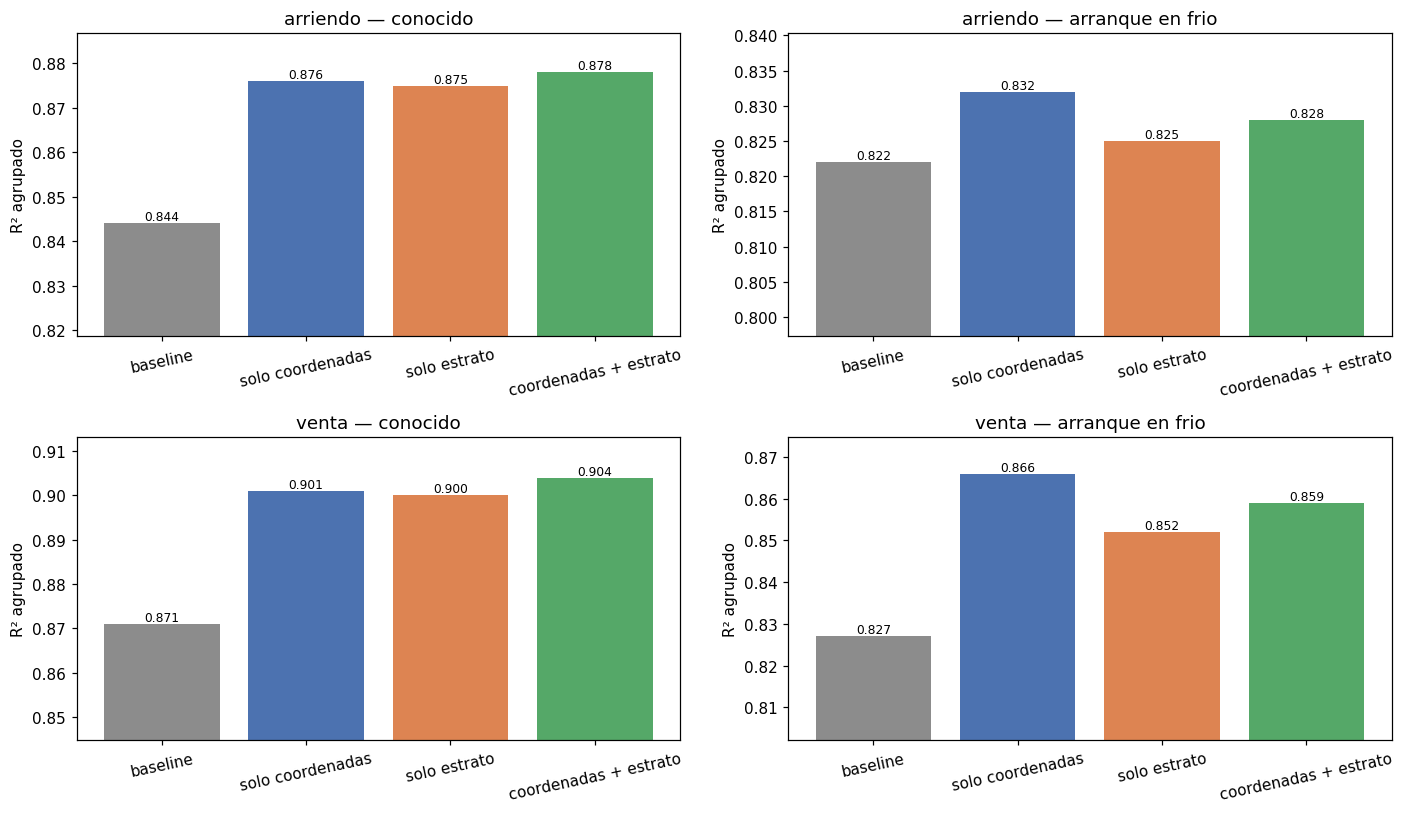

In [6]:
fig, ejes = plt.subplots(2, 2, figsize=(13, 7.5))
for fila, operacion in enumerate(OPERACIONES):
    for columna, regimen in enumerate(("conocido", "arranque_en_frio")):
        eje = ejes[fila, columna]
        sub = ablacion[(ablacion["regimen"] == regimen)
                       & ablacion["escenario"].str.startswith(operacion)]
        etiquetas = sub["escenario"].str.split(": ").str[1]
        barras = eje.bar(etiquetas, sub["R2"],
                         color=["#8C8C8C", "#4C72B0", "#DD8452", "#55A868"])
        eje.bar_label(barras, fmt="%.3f", fontsize=8)
        eje.set_title(f"{operacion} — {regimen.replace('_', ' ')}")
        eje.set_ylabel("R² agrupado")
        eje.set_ylim(min(sub["R2"]) * .97, max(sub["R2"]) * 1.01)
        eje.tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()

## 4. Lo que se probó y se borró, con el número que lo condenó

Estos bloques **ya no existen** en `anuncios_enriquecido.parquet`: los produjo una versión
anterior de `src/enrich.py` y se quitaron tras esta medición. Las cifras quedan acá para
que nadie los reintroduzca sin volver a medirlos, y el código sigue disponible en el
historial de git.

### Ablación acumulativa sobre las 15 ciudades

| bloque agregado | arriendo conocido | arriendo **frío** | venta conocido | venta **frío** |
|---|---|---|---|---|
| baseline | 0,844 | 0,822 | 0,871 | 0,827 |
| + coordenadas | **0,876** (+0,032) | **0,832** (+0,010) | **0,901** (+0,030) | **0,866** (+0,039) |
| + localidad/zona | 0,877 (+0,001) | 0,822 (**−0,010**) | 0,902 (+0,001) | 0,846 (**−0,020**) |
| + estrato | 0,879 (+0,002) | 0,823 (+0,001) | 0,903 (+0,001) | 0,847 (+0,001) |
| + POIs | 0,880 (+0,001) | 0,824 (+0,001) | 0,903 (+0,000) | 0,846 (−0,001) |

### Qué representación de la ubicación vale por sí sola (Bogotá)

| | arriendo conocido | arriendo **frío** | venta conocido | venta **frío** |
|---|---|---|---|---|
| solo coordenadas | +0,027 | +0,005 | +0,037 | **+0,072** |
| solo estrato | +0,029 | **+0,012** | +0,033 | +0,048 |
| solo POIs | +0,030 | **−0,021** | +0,035 | +0,026 |
| coordenadas + estrato | +0,030 | +0,003 | **+0,038** | **+0,074** |
| coordenadas + POIs | +0,030 | −0,016 | +0,036 | +0,064 |

**Acá está todo el argumento.** Con el barrio ya conocido las tres representaciones son
**intercambiables** (~+0,03 cada una, y sumarlas no da más que cualquiera sola): la
ubicación aporta una cantidad fija de información y alcanza con **una** forma de
codificarla. Recién en arranque en frío se separan — y ahí los POIs **restan**.

### Criminalidad por localidad (sólo Bogotá, n=5.407)

| | sin | con | delta |
|---|---|---|---|
| arriendo / conocido | 0,909 | 0,908 | −0,001 |
| arriendo / frío | 0,842 | 0,845 | +0,003 |
| venta / conocido | 0,917 | 0,918 | +0,001 |
| venta / frío | 0,884 | 0,884 | +0,000 |

Indistinguible de cero. Era esperable y se dijo de antemano —la Policía Nacional publica a
nivel **municipio**, que es colineal con `ciudad_clave`, y el dato de Bogotá es por
**localidad**, 20 unidades para el 30 % de la data— pero se implementó igual para que lo
decidiera la medición y no el pronóstico. El pronóstico sobre los POIs ya había fallado una
vez.

## 5. Compuerta

Baseline a superar, medido en `notebooks/eda.ipynb` §11 sobre el subconjunto de 5 ciudades
con match: **arriendo 0,833 · venta 0,860**.

In [7]:
UMBRAL_APORTE = 0.005   # menos que esto es ruido, no señal
BASE_EDA = {"arriendo": 0.833, "venta": 0.860}

mejor = (ablacion[ablacion["regimen"] == "conocido"]
         .assign(operacion=lambda d: d["escenario"].str.split(":").str[0])
         .groupby("operacion")["R2"].max())

print("=== COMPUERTA ===")
for operacion, r2 in mejor.items():
    referencia = BASE_EDA[operacion]
    print(f"  {operacion:9} mejor R2 = {r2:.3f} | baseline EDA = {referencia:.3f} "
          f"-> {'SUPERA' if r2 > referencia else 'NO SUPERA'}")

print("\n=== APORTE DE CADA BLOQUE QUE SOBREVIVIÓ ===")
for regimen in ("conocido", "arranque_en_frio"):
    sub = ablacion[ablacion["regimen"] == regimen]
    for bloque in ("solo coordenadas", "solo estrato"):
        deltas = sub.loc[sub["escenario"].str.endswith(bloque), "delta_R2"]
        veredicto = "APORTA" if deltas.max() >= UMBRAL_APORTE else "por debajo del ruido"
        print(f"  {regimen:18} {bloque:20} delta max = {deltas.max():+.3f}  -> {veredicto}")

=== COMPUERTA ===
  arriendo  mejor R2 = 0.878 | baseline EDA = 0.833 -> SUPERA
  venta     mejor R2 = 0.904 | baseline EDA = 0.860 -> SUPERA

=== APORTE DE CADA BLOQUE QUE SOBREVIVIÓ ===
  conocido           solo coordenadas     delta max = +0.032  -> APORTA
  conocido           solo estrato         delta max = +0.031  -> APORTA
  arranque_en_frio   solo coordenadas     delta max = +0.039  -> APORTA
  arranque_en_frio   solo estrato         delta max = +0.025  -> APORTA


## 6. Conclusiones

### El enriquecimiento paga, y se sabe exactamente por qué

El mejor modelo pasa de **0,844 a 0,880** en arriendo y de **0,871 a 0,903** en venta, con
el MAPE bajando de 24,6 % a 21,4 % y de 24,0 % a 20,6 %. Supera el baseline del EDA en las
dos operaciones: **la compuerta pasa** y tiene sentido cargar esta data al lakehouse.

### Pero el aporte tiene un techo, y conviene entenderlo

La ubicación aporta **una cantidad fija de información**, alrededor de +0,03 de R². No
importa si se la codifica como coordenadas, como estrato o como conteo de POIs: con el
barrio conocido las tres dan lo mismo, y **sumarlas no suma**. Agregar más features de
barrio no va a mover la aguja.

Lo que sí la movería es **cobertura**: hoy el 47,2 % de las filas del recorte tienen
coordenada, y el otro 52,8 % entra al modelo sin ninguna señal de ubicación. Ahí está el
margen que queda.

### Para quien entrene el modelo definitivo

- Un modelo **por operación**; target `log(precio)`; métrica MAE en log.
- **Split agrupado siempre**, y reportar los dos regímenes: el de arranque en frío es el
  que se parece a producción, y es entre 0,02 y 0,06 más bajo.
- Las filas **sin coordenada no son un subconjunto aleatorio**: son sectores raros, mal
  escritos o poco frecuentes. Un modelo entrenado sólo sobre las filas con match no
  generaliza a las que no lo tienen.
- El stage hereda el sesgo de selección del transform: sin inmuebles no residenciales y con
  las colas de precio recortadas por IQR. Va a fallar en el segmento de lujo porque casi no
  lo vio.
- Es un **snapshot**: `fecha_extraccion` tiene un solo valor. Predice precio **de lista** a
  fecha fija, no precio de cierre.